In [20]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [8]:
df = pd.read_csv("C:/Users/tejas/Downloads/imdb-movies-dataset.csv/imdb-movies-dataset.csv")

In [9]:
df

,Poster,Title,Year,Certificate,Duration (min),Genre,Rating,Metascore,Director,Cast,Votes,Description,Review Count,Review Title,Review
0,https://m.media-amazon.com/images/M/MV5BYWRkZj...,The Idea of You,2023.0,R,115.0,"Comedy, Drama, Romance",6.4,67.0,Michael Showalter,"Anne Hathaway, Nicholas Galitzine, Ella Rubin,...","28,744","Solène, a 40-year-old single mom, begins an un...",166,Hypocrisy as an idea,"This film, as well as the reaction to it, is a..."
1,https://m.media-amazon.com/images/M/MV5BZGI4NT...,Kingdom of the Planet of the Apes,2023.0,PG-13,145.0,"Action, Adventure, Sci-Fi",7.3,66.0,Wes Ball,"Owen Teague, Freya Allan, Kevin Durand, Peter ...","22,248","Many years after the reign of Caesar, a young ...",183,A phenomenal start to another trilogy!,"I'm a big fan of all the planet of the apes, a..."
2,https://m.media-amazon.com/images/M/MV5BZjIyOT...,Unfrosted,2023.0,PG-13,97.0,"Biography, Comedy, History",5.5,42.0,Jerry Seinfeld,"Isaac Bae, Jerry Seinfeld, Chris Rickett, Rach...","18,401","In 1963 Michigan, business rivals Kellogg's an...",333,not funny,Pretty much the worst criticism you can lay on...
3,https://m.media-amazon.com/images/M/MV5BMjA5Zj...,The Fall Guy,2023.0,PG-13,126.0,"Action, Comedy, Drama",7.3,73.0,David Leitch,"Ryan Gosling, Emily Blunt, Aaron Taylor-Johnso...","38,953",A down-and-out stuntman must find the missing ...,384,Everything you needed and more!,Just got out of the Austin premier at SXSW and...
4,https://m.media-amazon.com/images/M/MV5BNTk1MT...,Challengers,2023.0,R,131.0,"Drama, Romance, Sport",7.7,82.0,Luca Guadagnino,"Zendaya, Mike Faist, Josh O'Connor, Darnell Ap...","32,517","Tashi, a former tennis prodigy turned coach, t...",194,"Watch ""Match Point"" instead",This is a tough one. I liked the concept and t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,https://m.media-amazon.com/images/M/MV5BMzg5MW...,The Greatest Show on Earth,2020.0,U,152.0,"Drama, Family, Romance",6.5,76.0,Cecil B. DeMille,"James Stewart, Charlton Heston, Betty Hutton, ...","16,078","The dramatic lives of trapeze artists, a clown...",128,"Hey, doesn't anyone remember Last Emperor?",It constantly amazes me that people carp that ...
9996,https://m.media-amazon.com/images/M/MV5BYzA0ZG...,Berserk: Ougon Jidai-hen I - Haou no Tamago,2020.0,NaN,76.0,"Animation, Action, Adventure",7.5,NaN,Toshiyuki Kubooka,"Hiroaki Iwanaga, Carrie Keranen, Takahiro Saku...","14,300",A lone sellsword named Guts gets recruited int...,12,Masterfully directed climatic epic saga,Few stories can capture your mind and soul in ...
9997,https://m.media-amazon.com/images/M/MV5BM2U1Mj...,Is-slottet,2020.0,NaN,78.0,"Mystery, Drama",6.5,NaN,Per Blom,"Line Storesund, Hilde Nyeggen Martinsen, Meret...",740,A couple of twelve-year-old Norwegian girls st...,4,Beautiful Film,"This film might not be to everyone's taste, it..."
9998,https://m.media-amazon.com/images/M/MV5BMTAwOD...,Loving Pablo,2020.0,A,123.0,"Biography, Crime, Drama",6.4,42.0,Fernando León de Aranoa,"Javier Bardem, Penélope Cruz, Peter Sarsgaard,...","22,447",A journalist strikes up a romantic relationshi...,84,That film should be in Spanish,Why anyone (the director?) made Spanish actors...


In [10]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejas\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [11]:
df['label'] = df['Rating'].apply(lambda x: 1 if x >= 7 else 0)

In [12]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [14]:
df['clean_review'] = df['Review'].astype(str).apply(clean_text)

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)

X = vectorizer.fit_transform(df['clean_review']).toarray()
y = df['label'].values

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from tensorflow.keras import layers

In [32]:
model = Sequential()

# Input Layer
model.add(layers.Dense(50, activation="relu", input_shape=(10000,)))

# Hidden Layers
model.add(layers.Dropout(0.3))
model.add(layers.Dense(50, activation="relu"))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(50, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

In [33]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [46]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9927 - loss: 0.0255 - val_accuracy: 0.7294 - val_loss: 1.7913
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9933 - loss: 0.0222 - val_accuracy: 0.7231 - val_loss: 1.9388
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9936 - loss: 0.0211 - val_accuracy: 0.7063 - val_loss: 2.0987
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9936 - loss: 0.0217 - val_accuracy: 0.7138 - val_loss: 2.1225
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9931 - loss: 0.0215 - val_accuracy: 0.7219 - val_loss: 2.0812
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9925 - loss: 0.0228 - val_accuracy: 0.7006 - val_loss: 2.1214
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9909 - loss: 0.0288 - val_accuracy: 0.7306 - val_loss: 2.1120
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9922 - loss: 0.0257 - val_accu

In [47]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7130 - loss: 2.4256
Accuracy: 0.7129999995231628


In [48]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


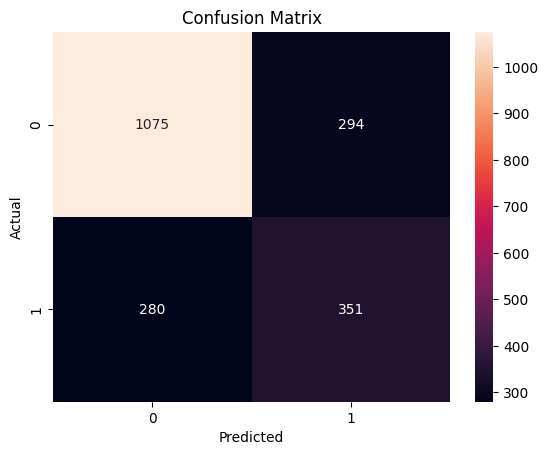

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [50]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1369
           1       0.54      0.56      0.55       631

    accuracy                           0.71      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.71      0.71      0.71      2000



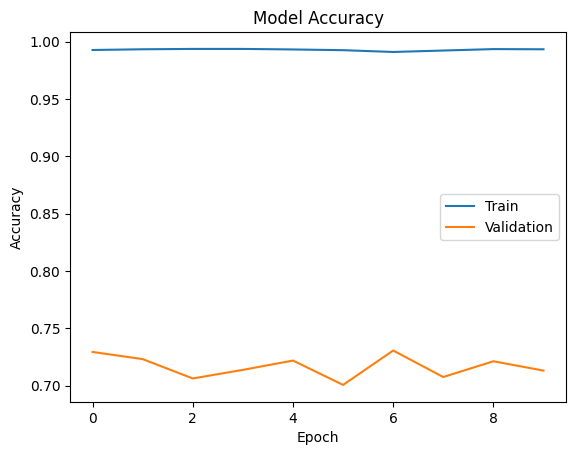

In [52]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


In [53]:
def predict_review(text):
    text = clean_text(text)

    # Convert using SAME TF-IDF vectorizer
    vector = vectorizer.transform([text]).toarray()

    pred = model.predict(vector)[0][0]

    if pred > 0.5:
        print("Positive Review 😊")
    else:
        print("Negative Review 😡")

In [54]:
predict_review("This movie was absolutely amazing and full of emotions!")
predict_review("Worst movie ever, waste of time.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Positive Review 😊
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Negative Review 😡


In [55]:
predict_review("The Last Airbender (2010), often cited for its terrible acting, poor special effects, and a rushed script that fails to honor the source materia")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Negative Review 😡


In [57]:
predict_review("Rue returns home from rehab and meets Jules; Nate and Maddy attempt to make each other jealous; Kat is pressured to lose something.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Negative Review 😡
